## Preparation

In [1]:
import os
from tqdm import tqdm
import numpy as np
# visualization
import matplotlib.pyplot as plt
from PIL import Image
# sklearn
from sklearn.model_selection import train_test_split
# pytorch
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# TODO: modify dataset path
IMAGE_PATH = "C:/Users/22156/Desktop/school/U 4/CS 484/A5/datasets/VOCdevkit/VOC2012/JPEGImages/"
MEAN = np.array([0.485, 0.456, 0.406])
STD = np.array([0.229, 0.224, 0.225])
TRAIN_SIZE = 0.8
IMG_SIZE = 224
BATCH_SIZE = 48

## Dataset

In [3]:
# get the list of all image paths
paths = [os.path.join(IMAGE_PATH, f) for f in os.listdir(IMAGE_PATH)]
# split paths into training and testing
paths_train, paths_test = train_test_split(
    paths, train_size=TRAIN_SIZE, random_state=484
)

In [4]:
# dataset class
class InpaintDataset(Dataset):
    def __init__(self, paths, img_transform=None):
        self.paths = paths
        self.img_transform = img_transform
    
    def __len__(self):
        return len(self.paths)
    
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx])
        if self.img_transform:
            img = self.img_transform(img)
        return img


In [5]:
# data augmentation
train_img_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(IMG_SIZE),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, hue=0.1),
    transforms.Normalize(MEAN, STD)
])
test_img_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(IMG_SIZE),
    transforms.RandomCrop(IMG_SIZE),
    transforms.Normalize(MEAN, STD)
])

# configure datasets
train_dataset = InpaintDataset(paths_train, train_img_transform)
test_dataset = InpaintDataset(paths_test, test_img_transform)

train_dataloader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True
)
test_dataloader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)

## Training Loop

In [6]:
def train_mae_gan(
        models, dataloader, optimizers, epochs, checkpoint_paths, mask_ratio=0.75,
        alpha_gan=0.2
    ):
    # unpack input
    generator, discriminator = models
    generator_optimizer, discriminator_optimizer = optimizers
    checkpoint_path_g, checkpoint_path_d = checkpoint_paths
    # losses for each epoch
    generator_losses, discriminator_losses, recon_losses = [], [], []
    patch_size = generator.patch_embed.patch_size[0]
    for epoch in range(epochs):
        print('-'*10)
        print(f'Epoch {epoch + 1}/{epochs}:')
        generator.train()
        discriminator.train()
        generator_loss, discriminator_loss, recon_loss = 0.0, 0.0, 0.0
        for x in tqdm(dataloader):
            x = x.to(DEVICE).float()
            n = x.shape[0]  # batch size
            ### Discriminator ###
            discriminator_optimizer.zero_grad()
            # pass real data through discriminator
            real_label = torch.full((n,), discriminator.REAL, dtype=torch.float, device=DEVICE)
            output = discriminator(x).view(-1)
            loss_d_real = discriminator.get_loss(output, real_label)
            loss_d_real.backward()
            # generate fake data
            loss_recon, pred_x, mask = generator(x, mask_ratio)
            fake_x = generator.unpatchify(pred_x)
            # TODO: decide whether to replace visible patches with ground truth
            mask = mask.detach()
            mask = mask.unsqueeze(-1).repeat(1, 1, patch_size**2 *3)  # (N, H*W, p*p*3)
            mask = generator.unpatchify(mask)  # 1 is removing, 0 is keeping
            fake_x = mask * fake_x + (1-mask) * x  # replace visible patches with ground truth
            # pass fake data through discriminator
            fake_label = torch.full((n,), discriminator.FAKE, dtype=torch.float, device=DEVICE)
            output = discriminator(fake_x.detach()).view(-1)
            loss_d_fake = discriminator.get_loss(output, fake_label)
            loss_d_fake.backward()
            # compute error for discriminator
            loss_d = loss_d_real + loss_d_fake
            discriminator_loss += loss_d.item()
            # update discriminator
            discriminator_optimizer.step()
            ### Generator ###
            generator_optimizer.zero_grad()
            # pass fake data through generator and discriminator
            output = discriminator(fake_x).view(-1)
            loss_g_fake = discriminator.get_loss(output, real_label)
            loss_g = alpha_gan * loss_g_fake + loss_recon
            loss_g.backward()
            # compute error for generator
            generator_loss += loss_g.item()
            recon_loss += loss_recon.item()
            # update generator
            generator_optimizer.step()

        epoch_recon_loss = recon_loss / len(dataloader)
        epoch_generator_loss = generator_loss / len(dataloader)
        epoch_discriminator_loss = discriminator_loss / len(dataloader) / 2
        recon_losses.append(epoch_recon_loss)
        generator_losses.append(epoch_generator_loss)
        discriminator_losses.append(epoch_discriminator_loss)
        print('Train reconstruction loss:', round(epoch_recon_loss, 4))
        print('Train generator loss:', round(epoch_generator_loss, 4))
        print('Train discriminator loss:', round(epoch_discriminator_loss, 4))
        
    # save final models
    torch.save(
        {'epoch': epoch,
         'model': generator.state_dict(),
         'optimizer': generator_optimizer.state_dict(),
         'loss': epoch_generator_loss},
        checkpoint_path_g
    )
    torch.save(
        {'epoch': epoch,
         'model': discriminator.state_dict(),
         'optimizer': discriminator_optimizer.state_dict(),
         'loss': epoch_discriminator_loss},
        checkpoint_path_d
    )
    return generator_losses, discriminator_losses, recon_losses

In [7]:
def train_mae_gan2(
        models, dataloader, optimizers, epochs, checkpoint_paths, mask_ratio=0.75,
        alpha_gan=0.2
    ):
    # unpack input
    generator, discriminator = models
    generator_optimizer, discriminator_optimizer = optimizers
    checkpoint_path_g, checkpoint_path_d = checkpoint_paths
    # losses for each epoch
    generator_losses, discriminator_losses, recon_losses = [], [], []
    patch_size = generator.patch_embed.patch_size[0]
    for epoch in range(epochs):
        print('-'*10)
        print(f'Epoch {epoch + 1}/{epochs}:')
        generator.train()
        discriminator.train()
        generator_loss, discriminator_loss, recon_loss = 0.0, 0.0, 0.0
        for x in tqdm(dataloader):
            x = x.to(DEVICE).float()
            ### Discriminator ###
            discriminator_optimizer.zero_grad()
            # generate fake data
            loss_recon, pred_x, mask = generator(x, mask_ratio)
            fake_x = generator.unpatchify(pred_x)
            # TODO: decide whether to replace visible patches with ground truth
            mask = mask.detach()
            mask_x = mask.unsqueeze(-1).repeat(1, 1, patch_size**2 *3)  # (N, H*W, p*p*3)
            mask_x = generator.unpatchify(mask_x)  # 1 is removing, 0 is keeping
            fake_x = mask_x * fake_x + (1-mask_x) * x  # replace visible patches with ground truth
            # pass fake data through discriminator
            output = discriminator(fake_x.detach())
            targets = torch.cat((torch.zeros(mask.shape[0], 1, device=DEVICE), 1-mask), dim=1)
            loss_d_fake = discriminator.get_loss(output, targets)
            loss_d_fake.backward()
            # pass real data through discriminator
            output = discriminator(x)
            targets = torch.ones(mask.shape[0], mask.shape[1]+1, device=DEVICE)
            loss_d_real = discriminator.get_loss(output, targets)
            loss_d_real.backward()
            # compute error for discriminator
            loss_d = loss_d_fake + loss_d_real
            discriminator_loss += loss_d.item()
            # update discriminator
            discriminator_optimizer.step()
            ### Generator ###
            generator_optimizer.zero_grad()
            # pass fake data through generator and discriminator
            output = discriminator(fake_x)
            targets = torch.cat((torch.zeros(mask.shape[0], 1, device=DEVICE), mask), dim=1)
            loss_g_fake = discriminator.get_loss(output, targets)
            loss_g = alpha_gan * loss_g_fake + loss_recon
            loss_g.backward()
            # compute error for generator
            generator_loss += loss_g.item()
            recon_loss += loss_recon.item()
            # update generator
            generator_optimizer.step()

        epoch_recon_loss = recon_loss / len(dataloader)
        epoch_generator_loss = generator_loss / len(dataloader)
        epoch_discriminator_loss = discriminator_loss / len(dataloader) / 2
        recon_losses.append(epoch_recon_loss)
        generator_losses.append(epoch_generator_loss)
        discriminator_losses.append(epoch_discriminator_loss)
        print('Train reconstruction loss:', round(epoch_recon_loss, 4))
        print('Train generator loss:', round(epoch_generator_loss, 4))
        print('Train discriminator loss:', round(epoch_discriminator_loss, 4))
        
    # save final models
    torch.save(
        {'epoch': epoch,
         'model': generator.state_dict(),
         'optimizer': generator_optimizer.state_dict(),
         'loss': epoch_generator_loss},
        checkpoint_path_g
    )
    torch.save(
        {'epoch': epoch,
         'model': discriminator.state_dict(),
         'optimizer': discriminator_optimizer.state_dict(),
         'loss': epoch_discriminator_loss},
        checkpoint_path_d
    )
    return generator_losses, discriminator_losses, recon_losses

In [8]:
def test_mae_gan(model, dataloader, mask_ratio=0.75):
    # losses for each epoch
    running_loss = 0.0
    model.eval()
    with torch.no_grad():
        for x in dataloader:
            x = x.to(DEVICE).float()
            loss, pred, mask = model(x, mask_ratio)
            running_loss += loss.item()
    loss = running_loss / len(dataloader)
    print('Test loss:', round(loss, 4))
    return loss

## Training

In [9]:
# build MAE encoder and generator
import models_mae

# TODO: download pretrained MAE weights
#!wget -nc https://dl.fbaipublicfiles.com/mae/visualize/mae_visualize_vit_large.pth checkpoints/mae_visualize_vit_large_gan.pth

arch = 'mae_vit_large_patch16'
generator = getattr(models_mae, arch)()

# load model
generator_path = 'checkpoints/mae_visualize_vit_large_0.2gan.pth'
checkpoint = torch.load(generator_path)
generator.load_state_dict(checkpoint['model'], strict=False)

<All keys matched successfully>

In [10]:
# freeze MAE encoder
for param in generator.patch_embed.parameters():
    param.requires_grad = False
generator.cls_token.requires_grad = False
generator.pos_embed.requires_grad = False
for param in generator.blocks.parameters():
    param.requires_grad = False
for param in generator.norm.parameters():
    param.requires_grad = False

generator = generator.to(DEVICE)

generator_optimizer = torch.optim.Adam(generator.parameters(), lr=1e-4, weight_decay=0.0)
# generator_optimizer.load_state_dict(checkpoint['optimizer'])

In [11]:
# build ViT discriminator
from models_disc import Discriminator2

discriminator = Discriminator2('vit_small_patch16_224')

# load model
discriminator_path = 'checkpoints/disc2_vit_small_patch16_224_0.2gan.pth'
checkpoint = torch.load(discriminator_path)
discriminator.load_state_dict(checkpoint['model'], strict=False)

<All keys matched successfully>

In [12]:
discriminator = discriminator.to(DEVICE)

discriminator_optimizer = torch.optim.Adam(discriminator.parameters(), lr=1e-4, weight_decay=0.0)
# discriminator_optimizer.load_state_dict(checkpoint['optimizer'])

In [ ]:
# train MAE-GAN
torch.random.seed()
epochs = 1  # TODO: modify
mae_gan_losses = train_mae_gan2(
    models=(generator, discriminator),
    dataloader=train_dataloader,
    optimizers=(generator_optimizer, discriminator_optimizer),
    epochs=epochs,
    checkpoint_paths=(generator_path, discriminator_path),
    alpha_gan=0.2
)

## Visualization

In [13]:
def show_image(image, title=''):
    # image is [H, W, 3]
    assert image.shape[2] == 3
    plt.imshow(torch.clip((image * STD + MEAN) * 255, 0, 255).int())
    plt.title(title, fontsize=16)
    plt.axis('off')
    return

def run_one_image(img, model, mask_ratio=0.75):
    x = torch.tensor(img, device=DEVICE)

    # make it a batch-like
    x = x.unsqueeze(dim=0)
    x = torch.einsum('nhwc->nchw', x)

    # run MAE
    model = model.to(DEVICE)
    loss, y, mask = model(x.float(), mask_ratio=mask_ratio)
    y = model.unpatchify(y)
    y = torch.einsum('nchw->nhwc', y).detach().cpu()

    # visualize the mask
    mask = mask.detach()
    mask = mask.unsqueeze(-1).repeat(1, 1, model.patch_embed.patch_size[0]**2 *3)  # (N, H*W, p*p*3)
    mask = model.unpatchify(mask)  # 1 is removing, 0 is keeping
    mask = torch.einsum('nchw->nhwc', mask).detach().cpu()
    
    x = torch.einsum('nchw->nhwc', x).detach().cpu()

    # masked image
    im_masked = x * (1 - mask)

    # MAE reconstruction pasted with visible patches
    im_paste = x * (1 - mask) + y * mask

    # make the plt figure larger
    plt.rcParams['figure.figsize'] = [24, 24]

    plt.subplot(2, 2, 1)
    show_image(x[0], "original")

    plt.subplot(2, 2, 2)
    show_image(im_masked[0], "masked")

    plt.subplot(2, 2, 3)
    show_image(y[0], "reconstruction")

    plt.subplot(2, 2, 4)
    show_image(im_paste[0], "reconstruction + visible")

    plt.show()

In [14]:
def resize_crop(img, dim):
    # resize and preserve aspect ratio
    if img.width < img.height:
        img = img.resize((dim, int(dim*img.height/img.width)))
    else:
        img = img.resize((int(224*img.width/img.height), dim))
    # crop the center of the image
    left = (img.width - dim)/2
    top = (img.height - dim)/2
    right = (img.width + dim)/2
    bottom = (img.height + dim)/2
    img = img.crop((left, top, right, bottom))
    return img

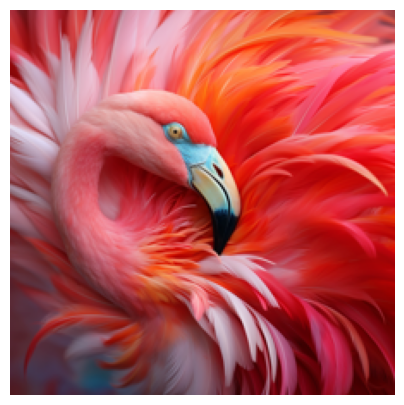

In [15]:
import requests

img_url = 'https://miro.medium.com/v2/resize:fit:1358/1*UKanEW04x1gOGa5rWZm2Qg.png'
# img_url = 'https://user-images.githubusercontent.com/11435359/147738734-196fd92f-9260-48d5-ba7e-bf103d29364d.jpg'
img = Image.open(requests.get(img_url, stream=True).raw)
img = resize_crop(img, dim=224)
img = np.array(img) / 255.

assert img.shape == (224, 224, 3)

# normalize by ImageNet mean and std
img = img - MEAN
img = img / STD

plt.rcParams['figure.figsize'] = [5, 5]
show_image(torch.tensor(img))

MAE-GAN:


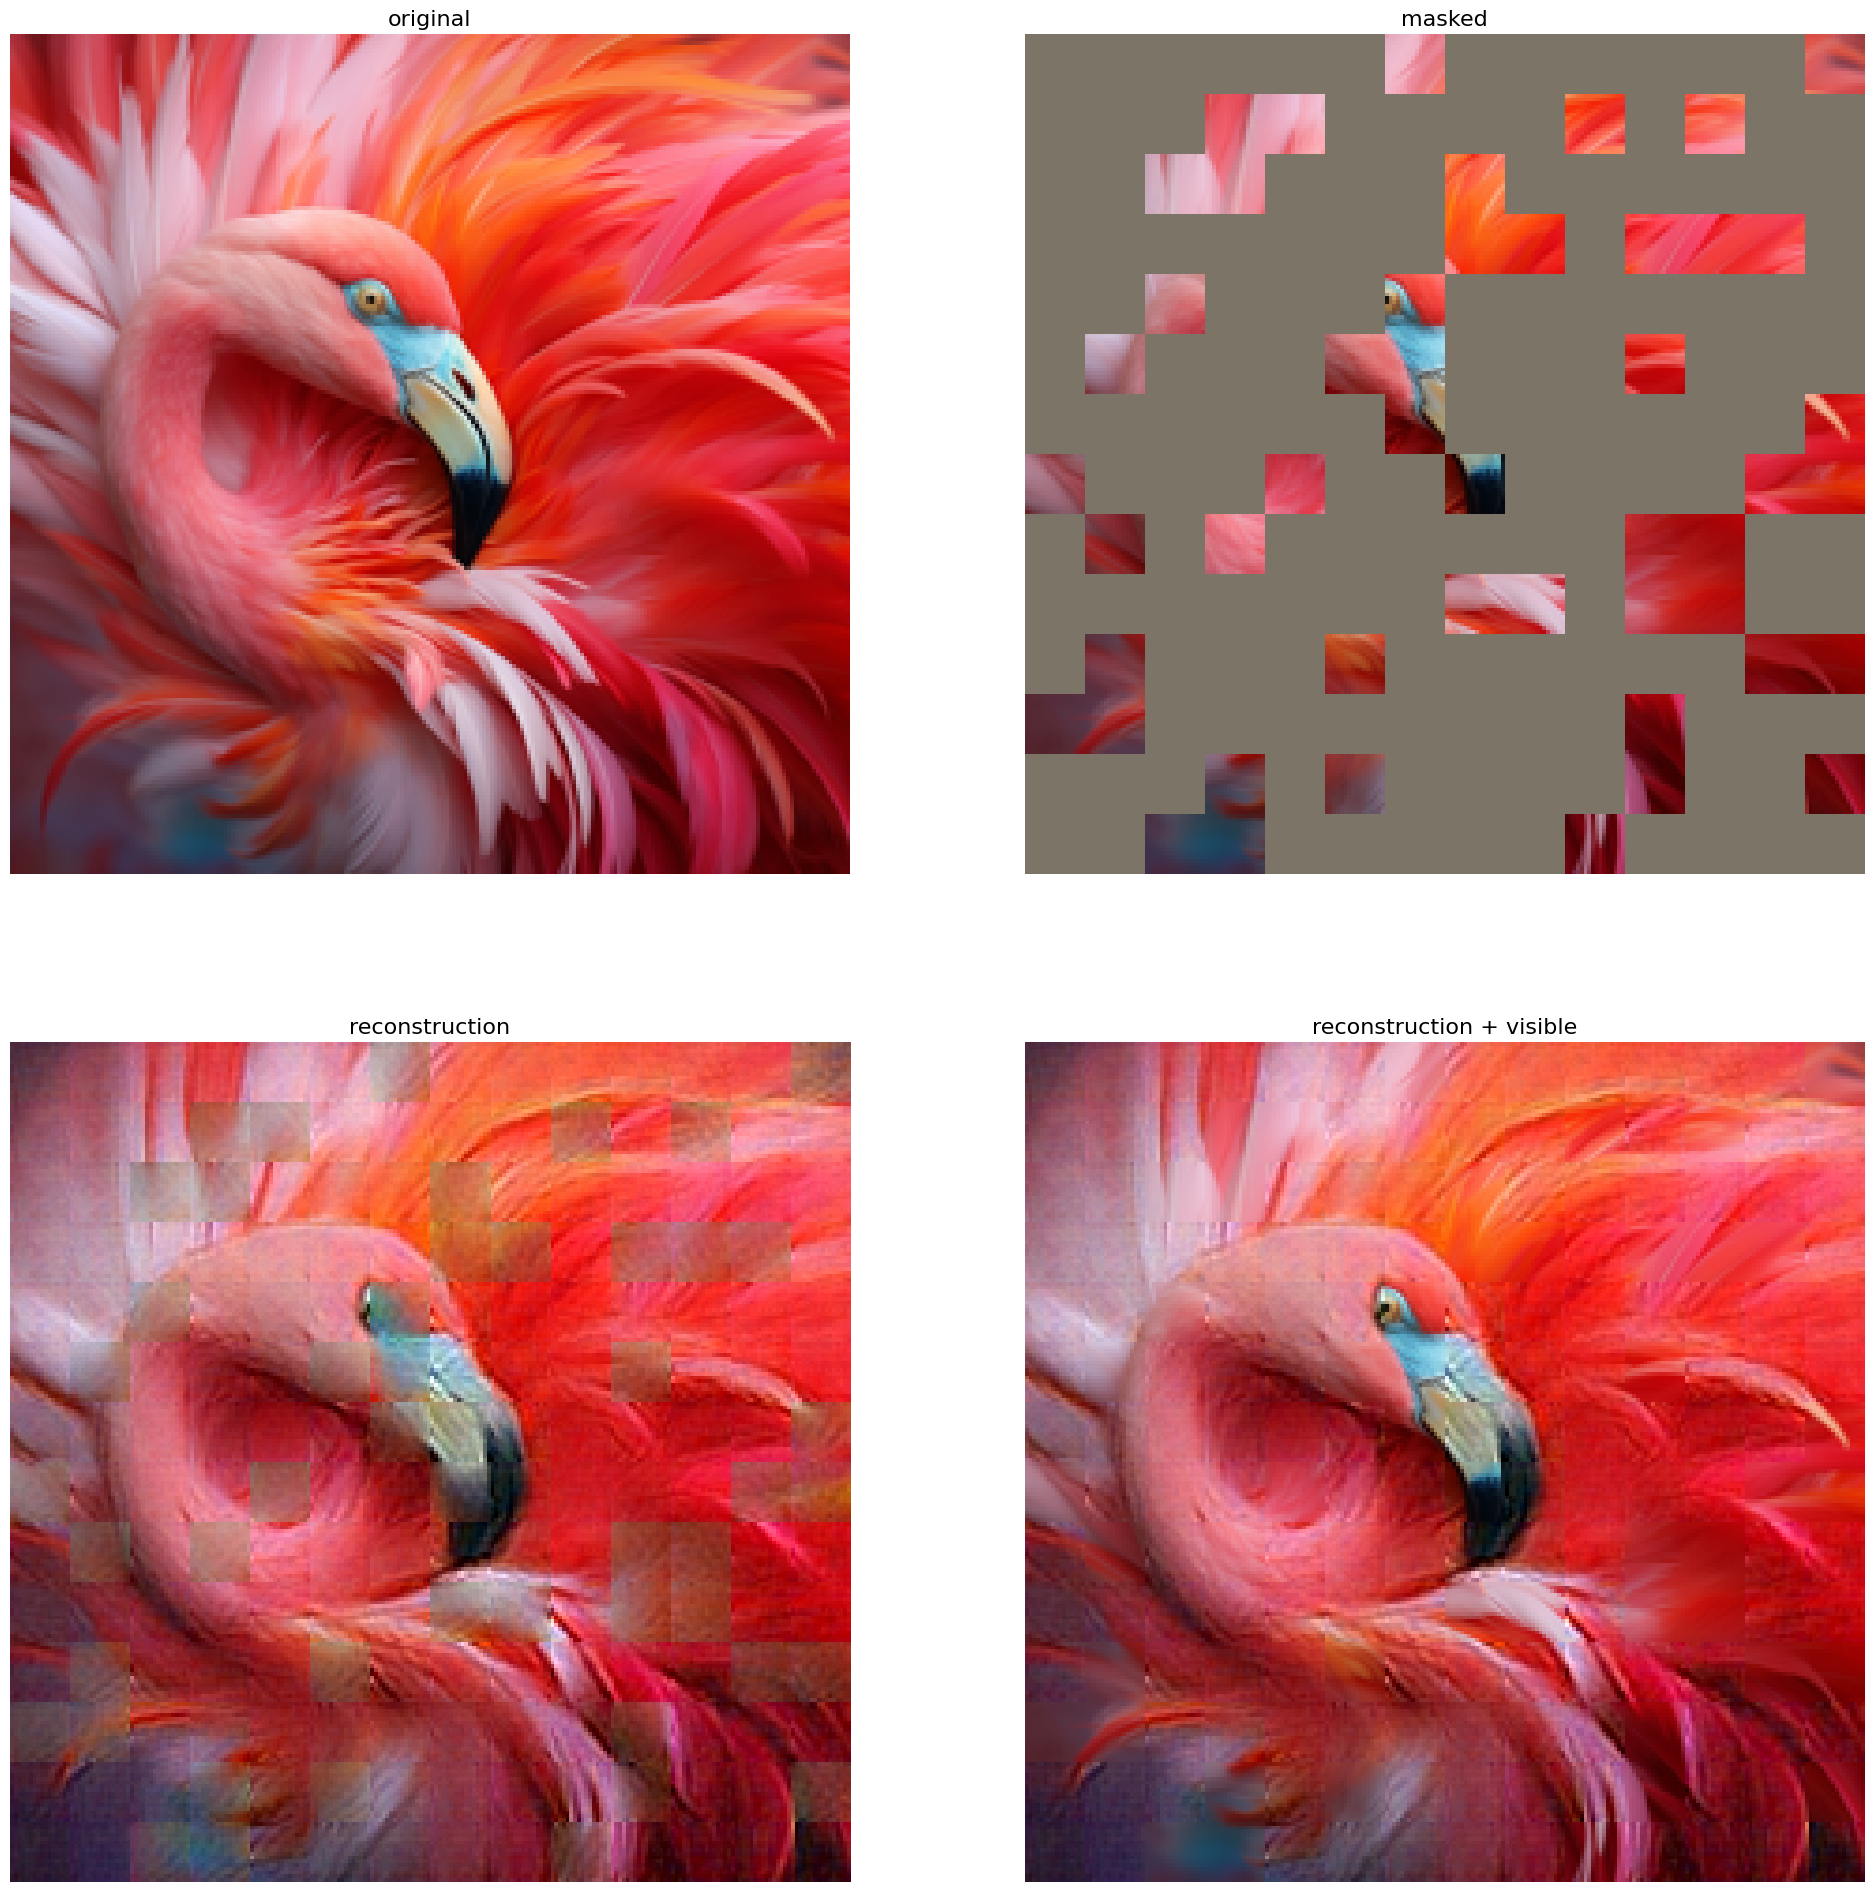

In [18]:
# make random mask reproducible
torch.manual_seed(2)
print('MAE-GAN:')
run_one_image(img, generator, mask_ratio=0.75)

In [19]:
plt.close()